In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [2]:
df = pd.read_csv("Social_Media_Dataset.csv", index_col='UserID')
df

,Age,Gender,Occupation,CommonPlatforms,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week,Country
UserID,,,,,,,,,,,,,
1,15.0,Male,Student,"Instagram, TikTok",1.4,8.0,7.434603,NaN,2,9,1.000000,NaN,Finland
2,19.0,Non-binary,Student,LinkedIn,4.3,3.0,3.470282,7.864055,5,8,1.000000,13.982044,Russia
3,25.0,Male,Student,YouTube,6.3,5.0,4.811788,4.200855,4,8,4.934264,14.583326,Brazil
4,17.0,Female,Student,"Instagram, TikTok",11.7,6.0,6.316027,3.794237,4,5,6.159886,18.779734,Australia
5,25.0,Female,Intern,YouTube,11.9,3.0,2.211295,7.066856,9,4,3.114569,21.949336,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,24.0,Female,Student,YouTube,10.7,NaN,5.000000,NaN,6,6,2.000000,NaN,United States
19997,23.0,Male,Student,"YouTube, Instagram",10.1,NaN,1.000000,10.000000,9,7,1.000000,14.000000,United States
19998,22.0,Male,Student,"Instagram, Snapchat",6.2,5.0,4.001702,6.087266,5,4,5.926741,24.516903,Italy


# Data Cleaning/Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20000
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           16079 non-null  float64
 1   Gender                        20000 non-null  object 
 2   Occupation                    20000 non-null  object 
 3   CommonPlatforms               20000 non-null  object 
 4   AvgDailyUsage                 16851 non-null  float64
 5   AnxietyScore_1_10             16906 non-null  float64
 6   DepressionScore_1_10          16973 non-null  float64
 7   SleepQuality_1_10             16336 non-null  float64
 8   SelfEsteem_1_10               20000 non-null  int64  
 9   LonelinessScore_1_10          20000 non-null  int64  
 10  StressScore_1_10              20000 non-null  float64
 11  OfflineInteractions_per_week  16533 non-null  float64
 12  Country                       20000 non-null  object 
dtypes: flo

In [4]:
df.isnull().sum()

Age                             3921
Gender                             0
Occupation                         0
CommonPlatforms                    0
AvgDailyUsage                   3149
AnxietyScore_1_10               3094
DepressionScore_1_10            3027
SleepQuality_1_10               3664
SelfEsteem_1_10                    0
LonelinessScore_1_10               0
StressScore_1_10                   0
OfflineInteractions_per_week    3467
Country                            0
dtype: int64

In [5]:
df['Gender'].value_counts()

Gender
Male          9606
Female        9595
Non-binary     799
Name: count, dtype: int64

In [6]:
df['Gender'].mode()

0    Male
Name: Gender, dtype: object

In [7]:
df.replace(to_replace='Non-binary',value='Male',inplace=True)

In [8]:
df['Gender'].value_counts()

Gender
Male      10405
Female     9595
Name: count, dtype: int64

In [9]:
df_numeric=df.select_dtypes(include='number')
df_numeric.describe()

,Age,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week
count,16079.000000,16851.000000,16906.000000,16973.000000,16336.000000,20000.000000,20000.000000,20000.000000,16533.000000
mean,21.917657,6.377632,5.515143,5.677297,5.000240,4.656200,5.514550,5.300284,20.801603
std,3.300486,3.526898,2.872779,2.990230,2.853851,2.850107,2.870767,2.839148,7.797764
min,13.000000,0.500000,1.000000,-0.292364,1.000000,1.000000,1.000000,1.000000,3.587302
25%,20.000000,3.400000,3.000000,3.027995,2.363887,2.000000,3.000000,3.000000,14.608496
50%,23.000000,6.300000,6.000000,5.681273,5.000000,5.000000,6.000000,5.124361,20.282986
75%,25.000000,9.300000,8.000000,8.135615,7.435697,7.000000,8.000000,8.000000,26.226380
max,25.000000,19.977184,10.000000,13.118043,10.000000,10.000000,10.000000,10.000000,42.000000


In [10]:
df_numeric.median()

Age                             23.000000
AvgDailyUsage                    6.300000
AnxietyScore_1_10                6.000000
DepressionScore_1_10             5.681273
SleepQuality_1_10                5.000000
SelfEsteem_1_10                  5.000000
LonelinessScore_1_10             6.000000
StressScore_1_10                 5.124361
OfflineInteractions_per_week    20.282986
dtype: float64

In [11]:
df.fillna({'Age':df['Age'].median()},inplace=True)

In [12]:
df.fillna({'AvgDailyUsage':df['AvgDailyUsage'].median()},inplace=True)
df.fillna({'AnxietyScore_1_10':df['AnxietyScore_1_10'].median()},inplace=True)
df.fillna({'DepressionScore_1_10':df['DepressionScore_1_10'].median()},inplace=True)
df.fillna({'SleepQuality_1_10':df['SleepQuality_1_10'].median()},inplace=True)
df.fillna({'OfflineInteractions_per_week':df['OfflineInteractions_per_week'].median()},inplace=True)

In [13]:
df.isnull().sum()

Age                             0
Gender                          0
Occupation                      0
CommonPlatforms                 0
AvgDailyUsage                   0
AnxietyScore_1_10               0
DepressionScore_1_10            0
SleepQuality_1_10               0
SelfEsteem_1_10                 0
LonelinessScore_1_10            0
StressScore_1_10                0
OfflineInteractions_per_week    0
Country                         0
dtype: int64

In [14]:
df.dtypes

Age                             float64
Gender                           object
Occupation                       object
CommonPlatforms                  object
AvgDailyUsage                   float64
AnxietyScore_1_10               float64
DepressionScore_1_10            float64
SleepQuality_1_10               float64
SelfEsteem_1_10                   int64
LonelinessScore_1_10              int64
StressScore_1_10                float64
OfflineInteractions_per_week    float64
Country                          object
dtype: object

# Dealing with inconsistent data types
-> float values should not appear in score/survey type datasets, (like self esteem and loneliness they should be in int type).


In [15]:
df['Age']=df['Age'].astype('int64')

In [16]:
df.dtypes

Age                               int64
Gender                           object
Occupation                       object
CommonPlatforms                  object
AvgDailyUsage                   float64
AnxietyScore_1_10               float64
DepressionScore_1_10            float64
SleepQuality_1_10               float64
SelfEsteem_1_10                   int64
LonelinessScore_1_10              int64
StressScore_1_10                float64
OfflineInteractions_per_week    float64
Country                          object
dtype: object

In [17]:
df

,Age,Gender,Occupation,CommonPlatforms,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week,Country
UserID,,,,,,,,,,,,,
1,15,Male,Student,"Instagram, TikTok",1.4,8.0,7.434603,5.000000,2,9,1.000000,20.282986,Finland
2,19,Male,Student,LinkedIn,4.3,3.0,3.470282,7.864055,5,8,1.000000,13.982044,Russia
3,25,Male,Student,YouTube,6.3,5.0,4.811788,4.200855,4,8,4.934264,14.583326,Brazil
4,17,Female,Student,"Instagram, TikTok",11.7,6.0,6.316027,3.794237,4,5,6.159886,18.779734,Australia
5,25,Female,Intern,YouTube,11.9,3.0,2.211295,7.066856,9,4,3.114569,21.949336,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,24,Female,Student,YouTube,10.7,6.0,5.000000,5.000000,6,6,2.000000,20.282986,United States
19997,23,Male,Student,"YouTube, Instagram",10.1,6.0,1.000000,10.000000,9,7,1.000000,14.000000,United States
19998,22,Male,Student,"Instagram, Snapchat",6.2,5.0,4.001702,6.087266,5,4,5.926741,24.516903,Italy


In [18]:
df_BadDtypes = df[['AvgDailyUsage','AnxietyScore_1_10','DepressionScore_1_10','SleepQuality_1_10','StressScore_1_10','OfflineInteractions_per_week']]

In [19]:
for i in df_BadDtypes:
    df[i]=df[i].astype('int64')

In [20]:
df.dtypes

Age                              int64
Gender                          object
Occupation                      object
CommonPlatforms                 object
AvgDailyUsage                    int64
AnxietyScore_1_10                int64
DepressionScore_1_10             int64
SleepQuality_1_10                int64
SelfEsteem_1_10                  int64
LonelinessScore_1_10             int64
StressScore_1_10                 int64
OfflineInteractions_per_week     int64
Country                         object
dtype: object

In [21]:
df

,Age,Gender,Occupation,CommonPlatforms,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week,Country
UserID,,,,,,,,,,,,,
1,15,Male,Student,"Instagram, TikTok",1,8,7,5,2,9,1,20,Finland
2,19,Male,Student,LinkedIn,4,3,3,7,5,8,1,13,Russia
3,25,Male,Student,YouTube,6,5,4,4,4,8,4,14,Brazil
4,17,Female,Student,"Instagram, TikTok",11,6,6,3,4,5,6,18,Australia
5,25,Female,Intern,YouTube,11,3,2,7,9,4,3,21,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,24,Female,Student,YouTube,10,6,5,5,6,6,2,20,United States
19997,23,Male,Student,"YouTube, Instagram",10,6,1,10,9,7,1,14,United States
19998,22,Male,Student,"Instagram, Snapchat",6,5,4,6,5,4,5,24,Italy


In [22]:
df['DepressionScore_1_10'] = df['DepressionScore_1_10'].clip(upper=10)

In [23]:
df['Occupation'].value_counts()

Occupation
Student       14937
Intern         4058
Unemployed     1005
Name: count, dtype: int64

In [24]:
df['Country'].value_counts()

Country
Australia         962
Nigeria           959
India             951
United States     944
Mexico            942
Germany           939
France            930
Philippines       919
Brazil            916
Denmark           911
Indonesia         905
United Kingdom    904
Kenya             903
South Africa      902
Canada            894
Finland           889
China             888
Russia            887
Argentina         887
Italy             887
New Zealand       861
Japan             820
Name: count, dtype: int64

# Exploding Colums for better insights into most commonly used Social Media Apps

In [25]:
df_exploded = df.copy()
df_exploded['CommonPlatforms']=df_exploded['CommonPlatforms'].str.split(',')
df_exploded=df_exploded.explode('CommonPlatforms')

In [26]:
df_exploded['CommonPlatforms']=df_exploded['CommonPlatforms'].str.strip().str.title()

In [27]:
Most_Popular_SM=df_exploded['CommonPlatforms'].value_counts()
Most_Popular_SM

CommonPlatforms
Youtube      15112
Instagram     7273
Tiktok        4880
Snapchat      1377
Reddit        1050
Twitter       1001
Pinterest      603
Facebook       583
Linkedin       399
Name: count, dtype: int64

# Data Visualization

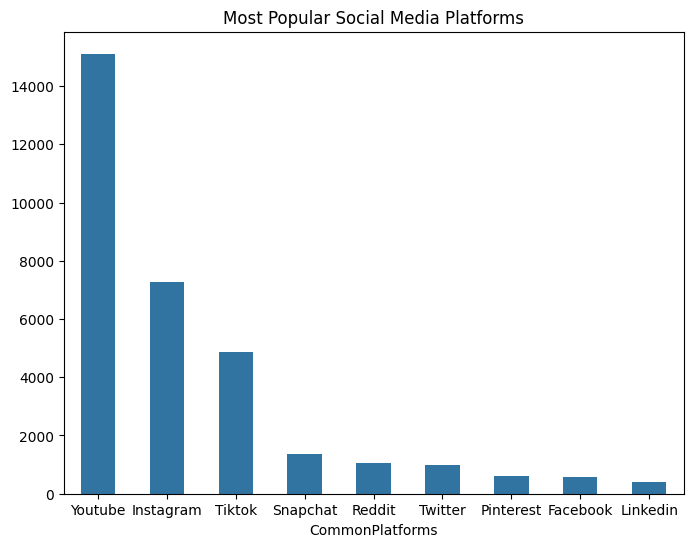

In [28]:
plt.figure(figsize=(8,6))
sns.barplot(x=Most_Popular_SM.index, y = Most_Popular_SM.values,width=0.5)
plt.title('Most Popular Social Media Platforms')
plt.show()

In [29]:
df['AvgDailyUsage'].value_counts()

AvgDailyUsage
6     4578
1     1528
11    1488
9     1475
3     1467
5     1443
7     1438
2     1436
4     1432
10    1422
8     1407
0      613
12      73
15      46
16      44
17      42
18      37
19      31
Name: count, dtype: int64

In [30]:
bins = [-1, 4, 9, 14, 19, float('inf')]
labels = ['Low Usage', 'Moderate Usage', 'High Usage', 'Very High Usage', 'Excessive Usage']

df['AvgDailyUsage_bins'] = pd.cut(df['AvgDailyUsage'], bins=bins, labels=labels, ordered=True)

In [31]:
df['AvgDailyUsage_bins'].value_counts()

AvgDailyUsage_bins
Moderate Usage     10341
Low Usage           6476
High Usage          2983
Very High Usage      200
Excessive Usage        0
Name: count, dtype: int64

In [32]:
df_filtered = df[df['AvgDailyUsage_bins'] != 'Excessive Usage'].copy()
df_filtered['AvgDailyUsage_bins'] = df_filtered['AvgDailyUsage_bins'].cat.remove_unused_categories() 

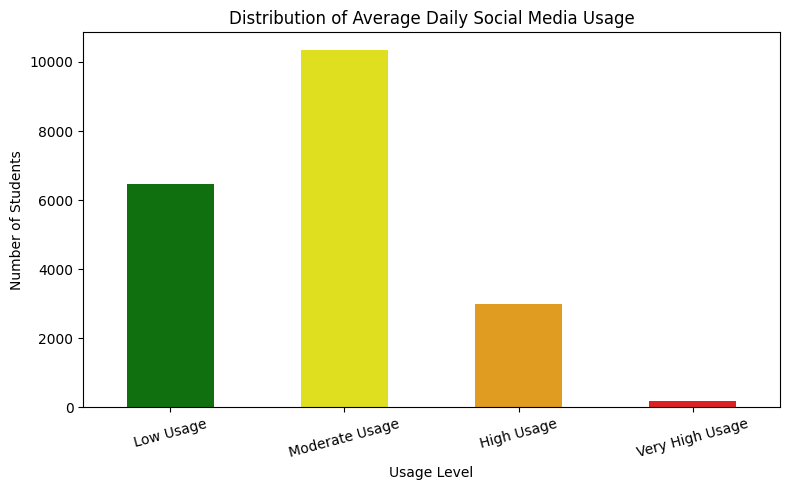

In [33]:
usage_colors = {
    'Low Usage': 'green',
    'Moderate Usage': 'yellow',
    'High Usage': 'orange',
    'Very High Usage': 'red'
}
usage_order = list(usage_colors.keys())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_filtered, x='AvgDailyUsage_bins', order=usage_order, hue = 'AvgDailyUsage_bins' , palette=usage_colors, width=0.5)

plt.title("Distribution of Average Daily Social Media Usage")
plt.xlabel("Usage Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

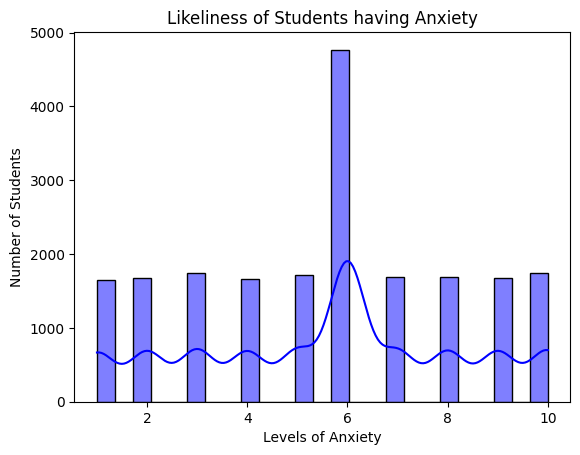

In [34]:
sns.histplot(df['AnxietyScore_1_10'], kde=True,color='blue')
plt.title("Likeliness of Students having Anxiety")
plt.ylabel("Number of Students")
plt.xlabel("Levels of Anxiety")
plt.show()

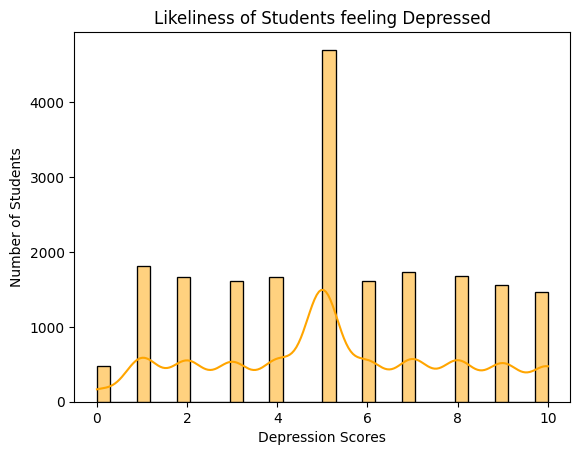

In [35]:
sns.histplot(df['DepressionScore_1_10'], kde=True,color='orange')
plt.title("Likeliness of Students feeling Depressed")
plt.ylabel("Number of Students")
plt.xlabel("Depression Scores")
plt.show()

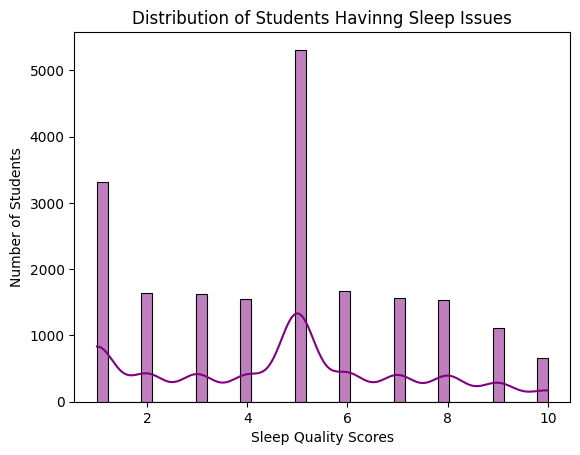

In [36]:
sns.histplot(df['SleepQuality_1_10'], kde=True,color='purple')
plt.title("Distribution of Students Havinng Sleep Issues")
plt.ylabel("Number of Students")
plt.xlabel("Sleep Quality Scores")
plt.show()

In [37]:
df.dtypes
df.nunique()

Age                             13
Gender                           2
Occupation                       3
CommonPlatforms                 10
AvgDailyUsage                   18
AnxietyScore_1_10               10
DepressionScore_1_10            11
SleepQuality_1_10               10
SelfEsteem_1_10                 10
LonelinessScore_1_10            10
StressScore_1_10                10
OfflineInteractions_per_week    40
Country                         22
AvgDailyUsage_bins               4
dtype: int64

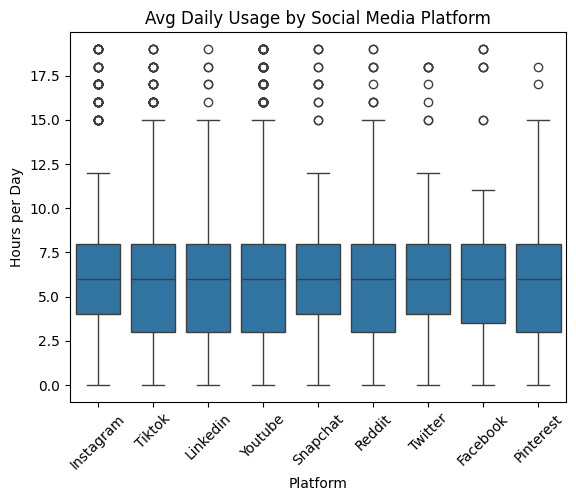

In [38]:
sns.boxplot(x='CommonPlatforms', y='AvgDailyUsage', data=df_exploded)
plt.xticks(rotation=45)
plt.title('Avg Daily Usage by Social Media Platform')
plt.xlabel('Platform')
plt.ylabel('Hours per Day')
plt.show()

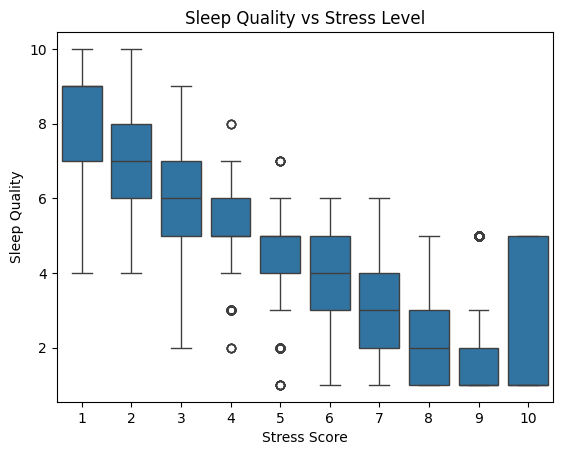

In [39]:
sns.boxplot(x='StressScore_1_10', y='SleepQuality_1_10', data=df)
plt.title('Sleep Quality vs Stress Level')
plt.xlabel('Stress Score')
plt.ylabel('Sleep Quality')
plt.show()

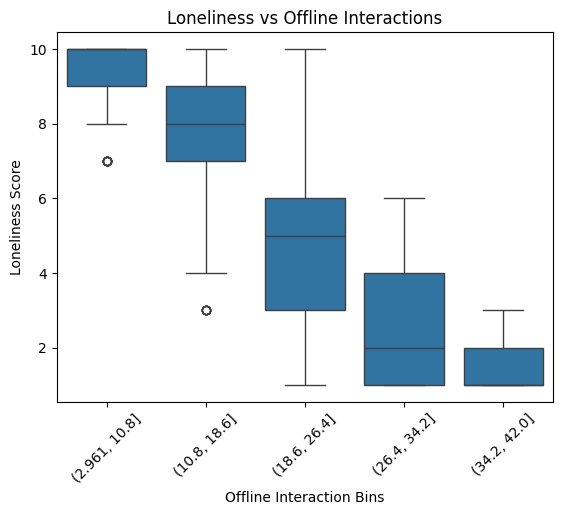

In [40]:
df['OfflineBin'] = pd.cut(df['OfflineInteractions_per_week'], bins=5)

sns.boxplot(x='OfflineBin', y='LonelinessScore_1_10', data=df)
plt.title('Loneliness vs Offline Interactions')
plt.xlabel('Offline Interaction Bins')
plt.ylabel('Loneliness Score')
plt.xticks(rotation=45)
plt.show()

In [41]:
df_corr = df.select_dtypes(include='number')
df_corr

,Age,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week
UserID,,,,,,,,,
1,15,1,8,7,5,2,9,1,20
2,19,4,3,3,7,5,8,1,13
3,25,6,5,4,4,4,8,4,14
4,17,11,6,6,3,4,5,6,18
5,25,11,3,2,7,9,4,3,21
...,...,...,...,...,...,...,...,...,...
19996,24,10,6,5,5,6,6,2,20
19997,23,10,6,1,10,9,7,1,14
19998,22,6,5,4,6,5,4,5,24


In [42]:
corr_matrix = df_corr.corr()
corr_matrix

,Age,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week
Age,1.000000,-0.001975,-0.003649,-0.001341,0.004957,0.004018,0.004804,-0.002007,-0.005081
AvgDailyUsage,-0.001975,1.000000,0.010534,0.007371,-0.010434,-0.011071,0.000176,0.008901,-0.002305
AnxietyScore_1_10,-0.003649,0.010534,1.000000,0.827451,-0.764677,-0.695656,-0.014576,0.677909,0.019965
DepressionScore_1_10,-0.001341,0.007371,0.827451,1.000000,-0.638073,-0.852903,-0.008620,0.556406,0.004042
SleepQuality_1_10,0.004957,-0.010434,-0.764677,-0.638073,1.000000,0.577178,0.004404,-0.827085,0.045383
SelfEsteem_1_10,0.004018,-0.011071,-0.695656,-0.852903,0.577178,1.000000,0.005262,-0.461878,0.053124
LonelinessScore_1_10,0.004804,0.000176,-0.014576,-0.008620,0.004404,0.005262,1.000000,-0.007467,-0.801436
StressScore_1_10,-0.002007,0.008901,0.677909,0.556406,-0.827085,-0.461878,-0.007467,1.000000,0.017105
OfflineInteractions_per_week,-0.005081,-0.002305,0.019965,0.004042,0.045383,0.053124,-0.801436,0.017105,1.000000


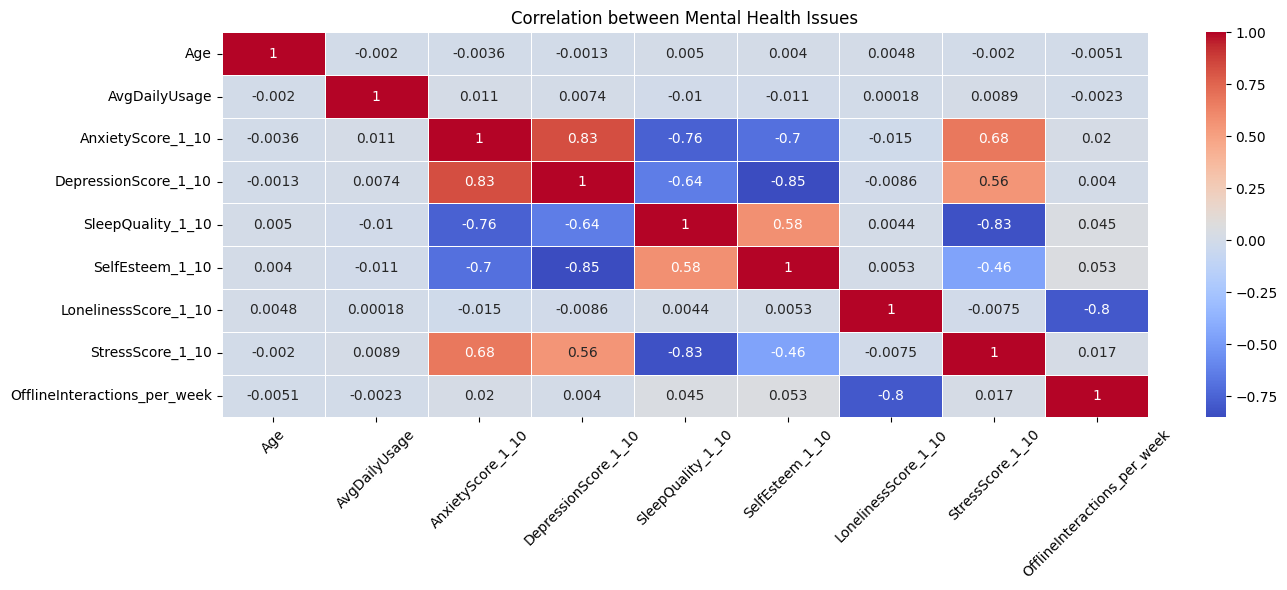

In [43]:
plt.figure(figsize=(14,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation between Mental Health Issues')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Best models for the ML training will be classification based models

* mainly those that can predict the risk level of a student being depressed
* for this we need to convert the score values to categorical columns

In [44]:
df['risk_class'] = df['DepressionScore_1_10'].apply(lambda x: 0 if x<=2 else 1 if x<=5 else 2)

In [45]:
label_map = {0:'no_risk',1:'medium',2:'high'}

In [46]:
df['risk_class'].value_counts()

risk_class
2    8058
1    7977
0    3965
Name: count, dtype: int64

In [47]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [48]:
df = pd.get_dummies(df, columns=['Occupation'], drop_first=False)

In [49]:
df

,Age,CommonPlatforms,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week,Country,AvgDailyUsage_bins,OfflineBin,risk_class,Gender_Male,Occupation_Intern,Occupation_Student,Occupation_Unemployed
UserID,,,,,,,,,,,,,,,,,,
1,15,"Instagram, TikTok",1,8,7,5,2,9,1,20,Finland,Low Usage,"(18.6, 26.4]",2,True,False,True,False
2,19,LinkedIn,4,3,3,7,5,8,1,13,Russia,Low Usage,"(10.8, 18.6]",1,True,False,True,False
3,25,YouTube,6,5,4,4,4,8,4,14,Brazil,Moderate Usage,"(10.8, 18.6]",1,True,False,True,False
4,17,"Instagram, TikTok",11,6,6,3,4,5,6,18,Australia,High Usage,"(10.8, 18.6]",2,False,False,True,False
5,25,YouTube,11,3,2,7,9,4,3,21,Australia,High Usage,"(18.6, 26.4]",0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,24,YouTube,10,6,5,5,6,6,2,20,United States,High Usage,"(18.6, 26.4]",1,False,False,True,False
19997,23,"YouTube, Instagram",10,6,1,10,9,7,1,14,United States,High Usage,"(10.8, 18.6]",0,True,False,True,False
19998,22,"Instagram, Snapchat",6,5,4,6,5,4,5,24,Italy,Moderate Usage,"(18.6, 26.4]",1,True,False,True,False


In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Age', 'AvgDailyUsage', 'AnxietyScore_1_10', 'DepressionScore_1_10',
       'SleepQuality_1_10', 'SelfEsteem_1_10', 'LonelinessScore_1_10',
       'StressScore_1_10', 'OfflineInteractions_per_week', 'risk_class'],
      dtype='object')

In [52]:
scaler = StandardScaler()

In [53]:
num_cols = num_cols.drop('risk_class')

In [54]:
num_cols

Index(['Age', 'AvgDailyUsage', 'AnxietyScore_1_10', 'DepressionScore_1_10',
       'SleepQuality_1_10', 'SelfEsteem_1_10', 'LonelinessScore_1_10',
       'StressScore_1_10', 'OfflineInteractions_per_week'],
      dtype='object')

In [55]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [56]:
df

,Age,CommonPlatforms,AvgDailyUsage,AnxietyScore_1_10,DepressionScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,OfflineInteractions_per_week,Country,AvgDailyUsage_bins,OfflineBin,risk_class,Gender_Male,Occupation_Intern,Occupation_Student,Occupation_Unemployed
UserID,,,,,,,,,,,,,,,,,,
1,-2.384353,"Instagram, TikTok",-1.521186,0.910417,0.656835,0.112956,-0.931988,1.214149,-1.447160,-0.058978,Finland,Low Usage,"(18.6, 26.4]",2,True,False,True,False
2,-1.046680,LinkedIn,-0.595853,-0.978532,-0.809805,0.895742,0.120630,0.865801,-1.447160,-1.036708,Russia,Low Usage,"(10.8, 18.6]",1,True,False,True,False
3,0.959831,YouTube,0.021036,-0.222953,-0.443145,-0.278437,-0.230243,0.865801,-0.384699,-0.897033,Brazil,Moderate Usage,"(10.8, 18.6]",1,True,False,True,False
4,-1.715516,"Instagram, TikTok",1.563258,0.154837,0.290175,-0.669830,-0.230243,-0.179242,0.323608,-0.338330,Australia,High Usage,"(10.8, 18.6]",2,False,False,True,False
5,0.959831,YouTube,1.563258,-0.978532,-1.176465,0.895742,1.524121,-0.527590,-0.738853,0.080698,Australia,High Usage,"(18.6, 26.4]",0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,0.625413,YouTube,1.254814,0.154837,-0.076485,0.112956,0.471503,0.169105,-1.093006,-0.058978,United States,High Usage,"(18.6, 26.4]",1,False,False,True,False
19997,0.290994,"YouTube, Instagram",1.254814,0.154837,-1.543125,2.069920,1.524121,0.517453,-1.447160,-0.897033,United States,High Usage,"(10.8, 18.6]",0,True,False,True,False
19998,-0.043424,"Instagram, Snapchat",0.021036,-0.222953,-0.443145,0.504349,0.120630,-0.527590,-0.030546,0.499725,Italy,Moderate Usage,"(18.6, 26.4]",1,True,False,True,False


In [57]:
X = df.drop(columns=['CommonPlatforms', 'DepressionScore_1_10', 'OfflineInteractions_per_week', 'Country', 'AvgDailyUsage_bins', 'OfflineBin', 'risk_class'], axis=1)
X.head()

,Age,AvgDailyUsage,AnxietyScore_1_10,SleepQuality_1_10,SelfEsteem_1_10,LonelinessScore_1_10,StressScore_1_10,Gender_Male,Occupation_Intern,Occupation_Student,Occupation_Unemployed
UserID,,,,,,,,,,,
1,-2.384353,-1.521186,0.910417,0.112956,-0.931988,1.214149,-1.447160,True,False,True,False
2,-1.046680,-0.595853,-0.978532,0.895742,0.120630,0.865801,-1.447160,True,False,True,False
3,0.959831,0.021036,-0.222953,-0.278437,-0.230243,0.865801,-0.384699,True,False,True,False
4,-1.715516,1.563258,0.154837,-0.669830,-0.230243,-0.179242,0.323608,False,False,True,False
5,0.959831,1.563258,-0.978532,0.895742,1.524121,-0.527590,-0.738853,False,True,False,False


In [58]:
y = df['risk_class']
y.head()

UserID
1    2
2    1
3    1
4    2
5    0
Name: risk_class, dtype: int64

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [61]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
y_pred = log_reg.predict(X_test)
print("Prediction:", y_pred)

Prediction: [2 2 0 ... 0 1 2]


In [63]:
y_test.values

array([2, 2, 1, ..., 0, 1, 2])

In [64]:
Accuracy = accuracy_score(y_test,y_pred)
Accuracy

0.831

In [65]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[ 594,  199,    0],
       [ 120, 1302,  173],
       [   0,  184, 1428]])

In [66]:
class_report = classification_report(y_test,y_pred)
print("Classification Report -\n",class_report)

Classification Report -
               precision    recall  f1-score   support

           0       0.83      0.75      0.79       793
           1       0.77      0.82      0.79      1595
           2       0.89      0.89      0.89      1612

    accuracy                           0.83      4000
   macro avg       0.83      0.82      0.82      4000
weighted avg       0.83      0.83      0.83      4000



In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_clf = RandomForestClassifier(
    n_estimators=200,     # Number of trees
    max_depth=None,       # Let trees grow fully (can tune later)
    random_state=42,      # Reproducibility
    class_weight='balanced'  # Handle class imbalance
)

In [69]:
rf_clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred_rf = rf_clf.predict(X_test)
y_pred_rf

array([2, 2, 0, ..., 0, 1, 2])

In [71]:
y_test.values

array([2, 2, 1, ..., 0, 1, 2])

In [72]:
acc_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)
print("\nConfusion Matrix:\n", conf_matrix_rf)
print("\nClassification Report:\n", class_report_rf)

Random Forest Accuracy: 0.87425

Confusion Matrix:
 [[ 675  118    0]
 [ 129 1295  171]
 [   0   85 1527]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       793
           1       0.86      0.81      0.84      1595
           2       0.90      0.95      0.92      1612

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [74]:
# Base model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Random search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,  # number of different combos to try
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [75]:
# Fit to training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [76]:
print("Best parameters found:", random_search.best_params_)
print("Best cross-val score:", random_search.best_score_)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best parameters found: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}
Best cross-val score: 0.875
Test Accuracy: 0.8865
Confusion Matrix:
 [[ 697   96    0]
 [ 132 1301  162]
 [   0   64 1548]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       793
           1       0.89      0.82      0.85      1595
           2       0.91      0.96      0.93      1612

    accuracy                           0.89      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.89      0.89      0.89      4000



In [77]:
importances = best_rf.feature_importances_
importances

array([0.01457607, 0.01786796, 0.43601176, 0.01485478, 0.47577006,
       0.01708623, 0.01368299, 0.00424158, 0.00226629, 0.00213717,
       0.0015051 ])

In [78]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [79]:
feature_importance_df["Importance (%)"] = 100 * feature_importance_df["Importance"]

In [80]:
feature_importance_df

,Feature,Importance,Importance (%)
4,SelfEsteem_1_10,0.475770,47.577006
2,AnxietyScore_1_10,0.436012,43.601176
1,AvgDailyUsage,0.017868,1.786796
5,LonelinessScore_1_10,0.017086,1.708623
3,SleepQuality_1_10,0.014855,1.485478
0,Age,0.014576,1.457607
6,StressScore_1_10,0.013683,1.368299
7,Gender_Male,0.004242,0.424158
8,Occupation_Intern,0.002266,0.226629
9,Occupation_Student,0.002137,0.213717


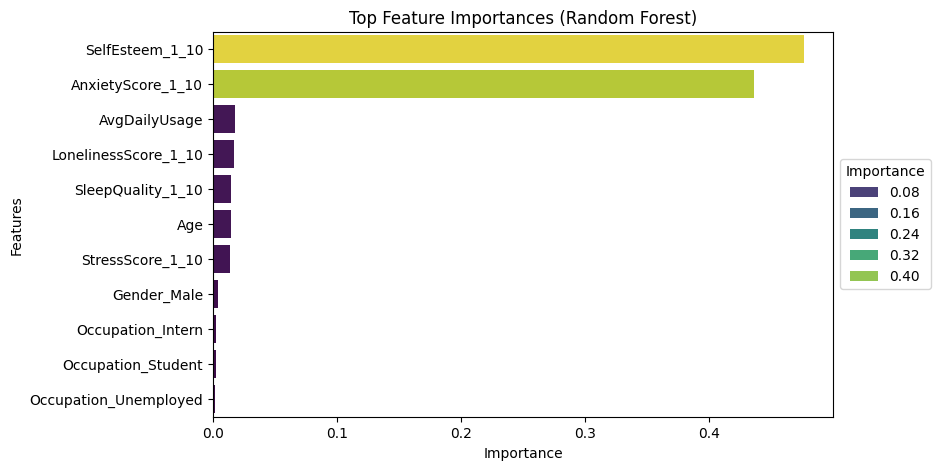

In [81]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df,hue='Importance',palette="viridis")
plt.title(f"Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.legend(title='Importance',loc='center left',bbox_to_anchor=(1,0.5))
plt.show()